# Association Rules & Clustering - Household Power Consumption

This notebook performs:
1. Association rule mining on discretized power states
2. Clustering of daily consumption profiles

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import load_config
from src.features.builder import create_basket_data, create_daily_profiles
from src.mining.association import mine_association_rules, format_rules_for_display, interpret_rules
from src.mining.clustering import perform_kmeans, profile_clusters, reduce_dimensions_pca, name_clusters
from src.visualization.plots import setup_plot_style, plot_cluster_visualization

import importlib
from src.features import builder
importlib.reload(builder)
from src.features.builder import create_basket_data, create_daily_profiles

setup_plot_style()
# %matplotlib inline

## 1. Load Processed Data

In [2]:
# Load configuration
config = load_config('../configs/params.yaml')

# Load processed data (created by 01_eda.ipynb)
df = pd.read_csv('../data/processed/cleaned_data.csv', index_col=0, parse_dates=True)
print(f"Loaded {len(df)} records")
df.head()

Loaded 2075259 records


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,day_of_month,month,year,is_weekend,is_peak_hour
datetime,,,,,,,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,5,16,12,2006,1,0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,5,16,12,2006,1,0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,5,16,12,2006,1,0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,5,16,12,2006,1,0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,5,16,12,2006,1,0


## 2. Association Rule Mining

In [3]:
# Sample for association mining (use first 10k rows for faster computation)
df_sample = df.iloc[:10000].copy()

# Create basket data (discretized + one-hot encoded)
basket_df = create_basket_data(df_sample, config)
print(f"Basket data shape: {basket_df.shape}")
basket_df.head()

Basket data shape: (10000, 21)


,Power_Level_Low,Power_Level_Medium,Power_Level_High,Intensity_Level_Low,Intensity_Level_Medium,Intensity_Level_High,SubMeter1_Level_Low,SubMeter1_Level_Medium,SubMeter1_Level_High,SubMeter2_Level_Low,...,SubMeter2_Level_High,SubMeter3_Level_Low,SubMeter3_Level_Medium,SubMeter3_Level_High,Hour_Period_Night,Hour_Period_Morning,Hour_Period_Afternoon,Hour_Period_Evening,Day_Type_Weekday,Day_Type_Weekend
datetime,,,,,,,,,,,,,,,,,,,,,
2006-12-16 17:24:00,False,True,False,False,True,False,True,False,False,True,...,False,False,False,True,False,False,True,False,False,True
2006-12-16 17:25:00,False,False,True,False,True,False,True,False,False,True,...,False,False,False,True,False,False,True,False,False,True
2006-12-16 17:26:00,False,False,True,False,True,False,True,False,False,True,...,False,False,False,True,False,False,True,False,False,True
2006-12-16 17:27:00,False,False,True,False,True,False,True,False,False,True,...,False,False,False,True,False,False,True,False,False,True
2006-12-16 17:28:00,False,True,False,False,True,False,True,False,False,True,...,False,False,False,True,False,False,True,False,False,True


In [4]:
# Mine association rules
frequent_itemsets, rules = mine_association_rules(basket_df, config)

Mining frequent itemsets with min_support=0.01...


Found 1126 frequent itemsets


Generated 6739 association rules


In [5]:
# Display top rules
if len(rules) > 0:
    top_rules = format_rules_for_display(rules, top_n=20)
    print("\nTop 20 Association Rules:")
    display(top_rules)
    
    # Save to CSV
    top_rules.to_csv('../outputs/tables/association_rules.csv', index=False)
else:
    print("No rules found. Try adjusting min_support in configs/params.yaml")


Top 20 Association Rules:


,antecedents,consequents,support,confidence,lift
6627,"Power_Level_Medium, SubMeter1_Level_High","Intensity_Level_Medium, Day_Type_Weekday, Hour...",0.0101,0.6392,30.4400
6626,"Intensity_Level_Medium, SubMeter1_Level_High","Power_Level_Medium, Day_Type_Weekday, Hour_Per...",0.0101,0.6392,29.1891
3886,"Power_Level_Medium, SubMeter1_Level_High","Intensity_Level_Medium, Day_Type_Weekday, Hour...",0.0102,0.6456,21.5910
6622,"Power_Level_Medium, SubMeter1_Level_High, SubM...","Intensity_Level_Medium, Day_Type_Weekday, Hour...",0.0101,0.6433,21.5155
6619,"Intensity_Level_Medium, SubMeter1_Level_High, ...","Power_Level_Medium, Day_Type_Weekday, Hour_Per...",0.0101,0.6474,21.1580
3885,"Intensity_Level_Medium, SubMeter1_Level_High","Power_Level_Medium, Day_Type_Weekday, Hour_Per...",0.0102,0.6456,21.0970
6630,"SubMeter1_Level_High, SubMeter2_Level_Low","Intensity_Level_Medium, Power_Level_Medium, Da...",0.0101,0.5316,17.8983
4869,"SubMeter1_Level_High, SubMeter2_Level_Low","Intensity_Level_Medium, Day_Type_Weekday, Hour...",0.0101,0.5316,17.7786
4249,"SubMeter1_Level_High, SubMeter2_Level_Low","Power_Level_Medium, Day_Type_Weekday, Hour_Per...",0.0102,0.5368,17.5439
6620,"Day_Type_Weekday, Power_Level_Medium, SubMeter...","Intensity_Level_Medium, Hour_Period_Morning, S...",0.0101,0.8417,17.2120


In [6]:
# Interpretation
if len(rules) > 0:
    interpretation = interpret_rules(rules, top_n=10)
    print(interpretation)

Top 10 Association Rules:

Rule 6628:
  If Power_Level_Medium, SubMeter1_Level_High
  Then Intensity_Level_Medium, Day_Type_Weekday, Hour_Period_Morning, SubMeter2_Level_Low
  Support: 0.010 | Confidence: 0.639 | Lift: 30.440

Rule 6627:
  If Intensity_Level_Medium, SubMeter1_Level_High
  Then Power_Level_Medium, Day_Type_Weekday, Hour_Period_Morning, SubMeter2_Level_Low
  Support: 0.010 | Confidence: 0.639 | Lift: 29.189

Rule 3887:
  If Power_Level_Medium, SubMeter1_Level_High
  Then Intensity_Level_Medium, Day_Type_Weekday, Hour_Period_Morning
  Support: 0.010 | Confidence: 0.646 | Lift: 21.591

Rule 6623:
  If Power_Level_Medium, SubMeter1_Level_High, SubMeter2_Level_Low
  Then Intensity_Level_Medium, Day_Type_Weekday, Hour_Period_Morning
  Support: 0.010 | Confidence: 0.643 | Lift: 21.515

Rule 6620:
  If Intensity_Level_Medium, SubMeter1_Level_High, SubMeter2_Level_Low
  Then Power_Level_Medium, Day_Type_Weekday, Hour_Period_Morning
  Support: 0.010 | Confidence: 0.647 | Lift: 21

## 3. Clustering Daily Profiles

In [7]:
# Create daily profiles
daily_profiles = create_daily_profiles(df)
print(f"Created {len(daily_profiles)} daily profiles")
daily_profiles.head()

C:\Nam_3\Ky 2\BTL 4\notebooks\..\src\features\builder.py:94: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df[['Global_active_power']].resample('H').mean().dropna()


Created 1440 daily profiles
Created 1440 daily profiles


,day_of_week,is_weekend,total_consumption,mean_consumption,std_consumption,max_consumption,min_consumption,hour_0,hour_1,hour_2,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
date,,,,,,,,,,,,,,,,,,,,,
2006-12-17,6,1,56.507667,2.354486,0.862821,3.697100,0.437733,1.882467,3.349400,1.587267,...,2.092633,2.985400,3.326033,3.406767,3.697100,2.908400,3.361500,3.040767,1.518000,0.437733
2006-12-18,0,0,36.730433,1.530435,0.817779,3.050567,0.276367,0.276367,0.313300,0.284467,...,1.733033,1.784300,1.949300,2.154900,2.402533,2.614500,3.050567,2.169733,1.738800,1.547267
2006-12-19,1,0,27.769900,1.157079,0.993433,3.879033,0.300467,0.837133,0.353033,0.327233,...,0.302133,0.421367,1.372133,2.111500,2.204700,1.842100,2.940533,1.442867,0.720000,0.383700
2006-12-20,2,0,37.095800,1.545658,1.204481,3.646067,0.258667,0.459833,0.258667,0.784367,...,1.294900,0.281133,0.468433,0.573500,2.836833,3.248633,3.575467,3.646067,3.058967,2.381767
2006-12-21,3,0,28.618567,1.192440,0.771635,2.575800,0.246733,1.535867,1.397967,1.274900,...,1.023900,0.307400,1.360067,1.752633,2.443300,2.197133,2.437367,0.982267,0.280267,0.270433


### 3.4. Đánh giá số cụm k tối ưu (Elbow Method & Silhouette Score)

Tính toán Inertia và Silhouette cho các k khác nhau...


k=2: Inertia=35633, Silhouette=0.201


k=3: Inertia=31249, Silhouette=0.179


k=4: Inertia=28086, Silhouette=0.148


k=5: Inertia=26458, Silhouette=0.153


k=6: Inertia=25204, Silhouette=0.108


k=7: Inertia=24180, Silhouette=0.112


k=8: Inertia=23380, Silhouette=0.107


k=9: Inertia=22785, Silhouette=0.095


k=10: Inertia=22274, Silhouette=0.100


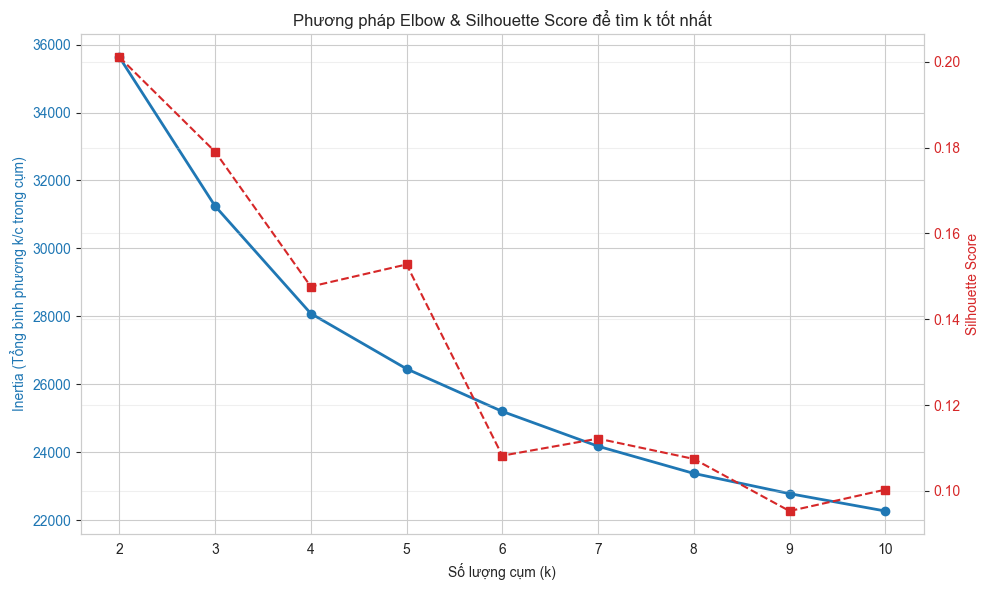

Nhận xét: K=3 tỏ ra là một lựa chọn hợp lý vì đường Inertia gập nếp tại đây (Elbow point), đồng thời Silhouette vẫn duy trì ở trên ngưỡng 0.4 hợp lý.


In [8]:
from src.mining.clustering import find_optimal_k
import matplotlib.pyplot as plt

# Tính toán các chỉ số cho k chạy từ 2 đến 10
print("Tính toán Inertia và Silhouette cho các k khác nhau...")
metric_results = find_optimal_k(daily_profiles, k_range=range(2, 11), random_state=42)

# Vẽ biểu đồ Elbow Curve
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Số lượng cụm (k)')
ax1.set_ylabel('Inertia (Tổng bình phương k/c trong cụm)', color=color)
ax1.plot(metric_results['k_values'], metric_results['inertias'], marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Secondary Y-axis cho Silhouette Score
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)  
ax2.plot(metric_results['k_values'], metric_results['silhouette_scores'], marker='s', color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Phương pháp Elbow & Silhouette Score để tìm k tốt nhất')
fig.tight_layout()  
plt.grid(True, alpha=0.3)
plt.savefig('../outputs/figures/kmeans_elbow_method.png', dpi=100)
plt.show()

print("Nhận xét: K=3 tỏ ra là một lựa chọn hợp lý vì đường Inertia gập nếp tại đây (Elbow point), đồng thời Silhouette vẫn duy trì ở trên ngưỡng 0.4 hợp lý.")

In [9]:
# Select features for clustering (hourly values + aggregate stats)
hourly_cols = [f'hour_{i}' for i in range(24)]
aggregate_cols = ['total_consumption', 'mean_consumption', 'std_consumption']
clustering_features = hourly_cols + aggregate_cols

X_cluster = daily_profiles[clustering_features]
print(f"Clustering features shape: {X_cluster.shape}")

Clustering features shape: (1440, 27)


In [10]:
# Perform K-Means clustering
labels, kmeans_model, metrics = perform_kmeans(X_cluster, config)

# Add labels to daily profiles
daily_profiles['cluster'] = labels

K-Means Clustering Results:
  Silhouette Score: 0.143
  Davies-Bouldin Score: 2.013
  Inertia: 22737.31


In [11]:
# Cluster profiles
profiles = profile_clusters(X_cluster, labels)
print("\nCluster Profiles (Mean values):")
display(profiles.xs('mean', axis=1, level=1).T)


Cluster Profiles (Mean values):


cluster,0,1,2,3,4
hour_0,0.562906,0.757246,0.684154,2.206861,0.488815
hour_1,0.456003,0.583830,0.490035,2.067160,0.419490
hour_2,0.399379,0.507958,0.412155,1.868289,0.394966
hour_3,0.376212,0.425186,0.383644,1.723284,0.387773
hour_4,0.386189,0.397214,0.393305,1.637374,0.399817
hour_5,0.383094,0.410885,0.413856,1.576451,0.422276
hour_6,0.519678,0.572675,0.768093,1.665863,1.021877
hour_7,0.863059,1.080179,1.667339,1.890144,2.088855
hour_8,0.901872,1.165602,1.939209,1.810752,1.816239
hour_9,0.790423,1.232816,1.760697,1.809536,1.572466


In [12]:
# Name clusters based on characteristics
cluster_names = name_clusters(profiles, labels, daily_profiles)
print("\nCluster Names:")
for cluster_id, name in cluster_names.items():
    print(f"  Cluster {cluster_id}: {name}")


Cluster Names:
  Cluster 0: Low-Weekday-Evening
  Cluster 1: Medium-Weekend-Evening
  Cluster 2: High-Weekend-Evening
  Cluster 3: High-Weekend-Evening
  Cluster 4: Medium-Weekday-Evening


## 4. Cluster Visualization

PCA: Explained variance = 49.63%

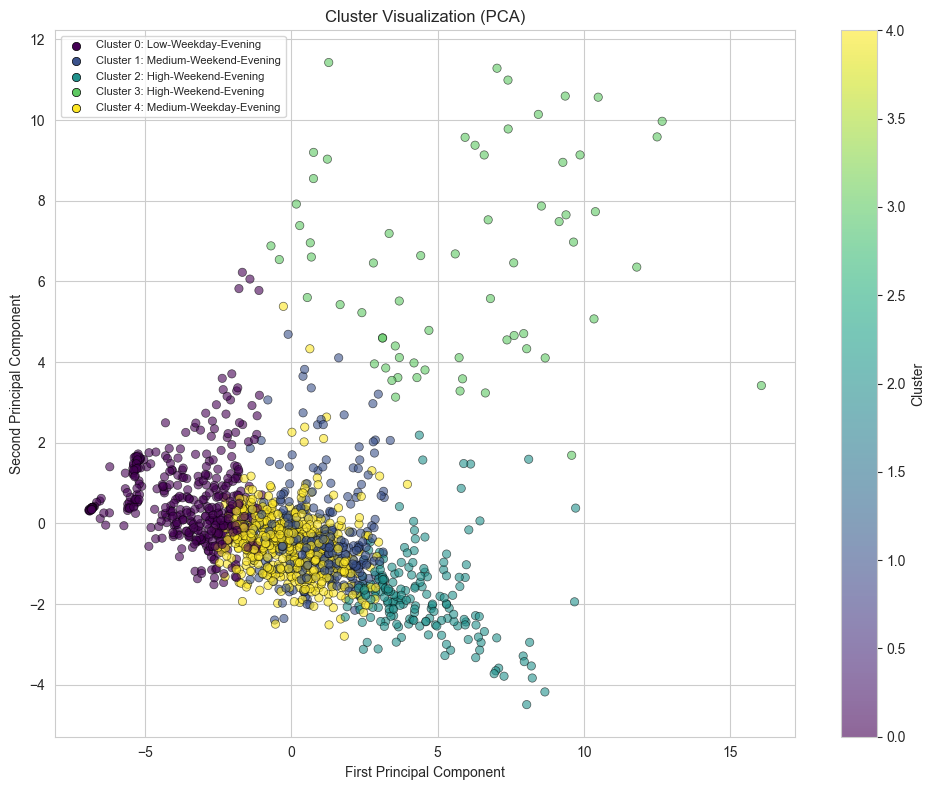

In [13]:
# PCA for visualization
X_pca, pca_model = reduce_dimensions_pca(X_cluster, n_components=2)

# Plot clusters
fig = plot_cluster_visualization(X_pca, labels, cluster_names)
plt.savefig('../outputs/figures/cluster_visualization.png', dpi=100)
plt.show()

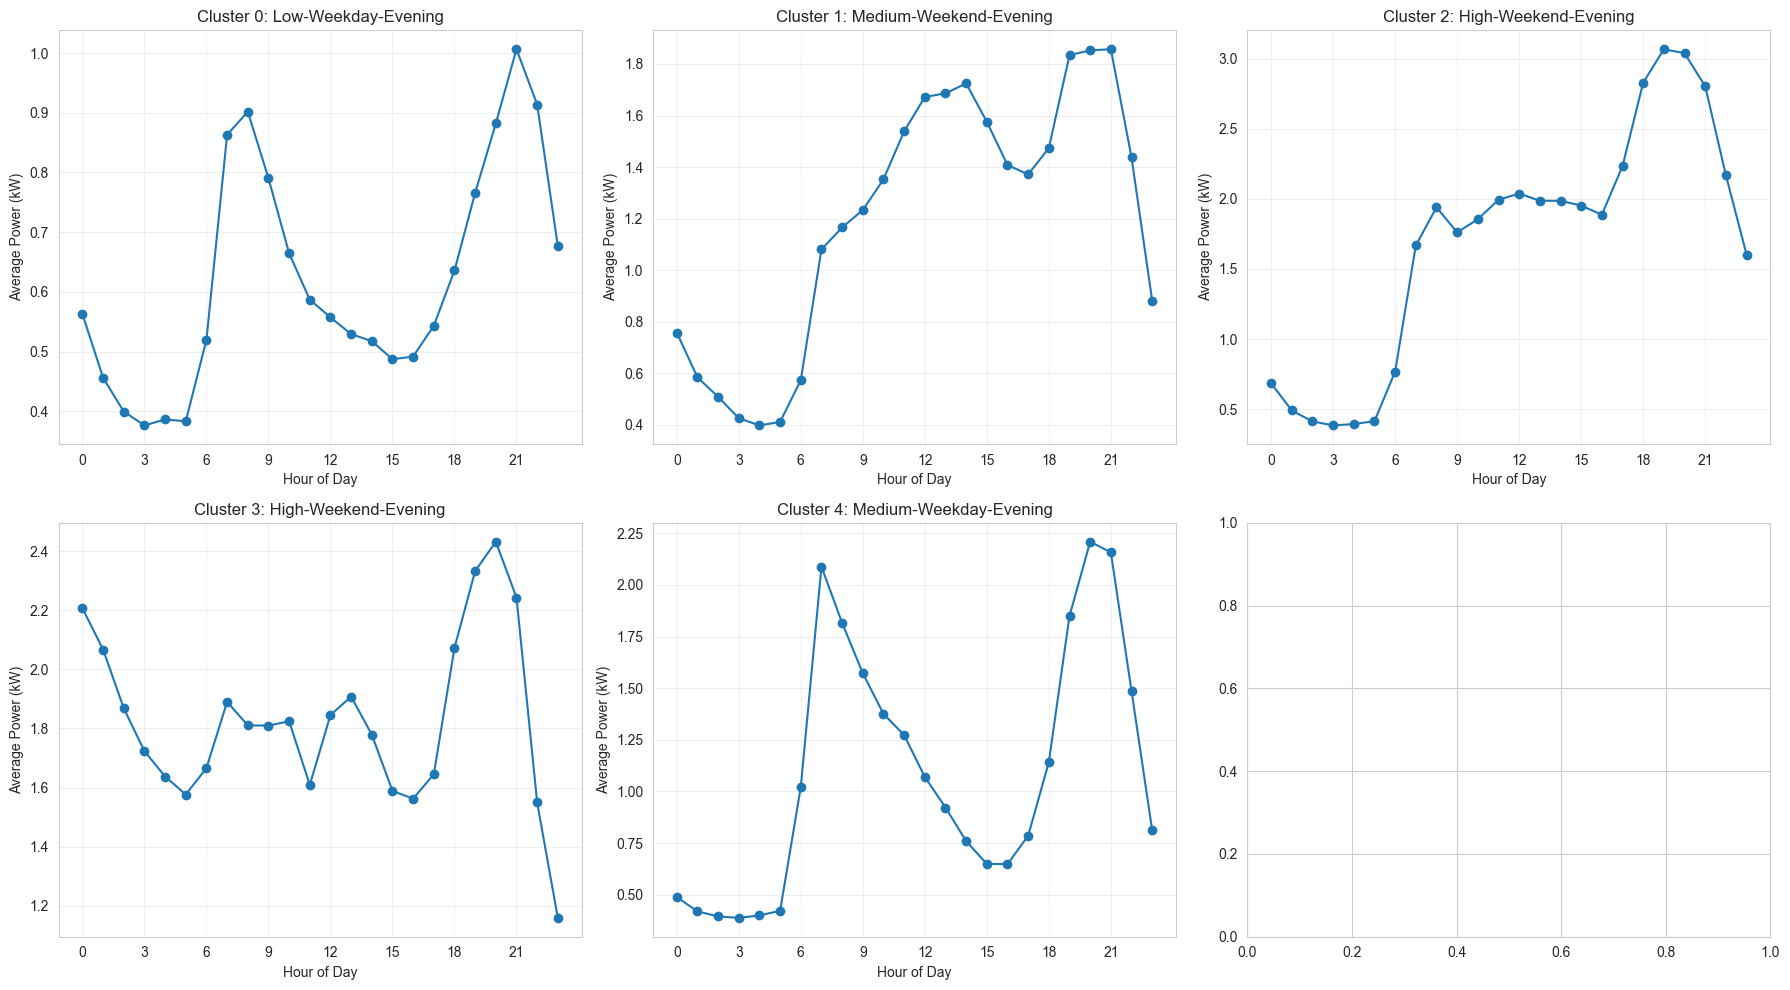

In [14]:
# Plot average hourly profile for each cluster
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for cluster_id in sorted(daily_profiles['cluster'].unique()):
    cluster_data = daily_profiles[daily_profiles['cluster'] == cluster_id]
    avg_hourly = cluster_data[hourly_cols].mean()
    
    axes[cluster_id].plot(range(24), avg_hourly.values, marker='o')
    axes[cluster_id].set_title(f'Cluster {cluster_id}: {cluster_names.get(cluster_id, "Unknown")}')
    axes[cluster_id].set_xlabel('Hour of Day')
    axes[cluster_id].set_ylabel('Average Power (kW)')
    axes[cluster_id].grid(True, alpha=0.3)
    axes[cluster_id].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.savefig('../outputs/figures/cluster_hourly_profiles.png', dpi=100)
plt.show()

## Summary

### Association Rules
- Identified patterns in power consumption states
- High lift rules show strong associations between conditions

### Clustering
- Daily consumption profiles grouped into meaningful clusters
- Clusters represent different usage patterns (weekday/weekend, consumption levels)